In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

df = pd.read_csv("heart_disease_uci.csv")
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [54]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [47]:
# -----------------------------
# Compare ranges of features
# -----------------------------
print("\nFeature Ranges:\n")

print("Cholesterol Range:")
print("Min:", df["chol"].min())
print("Max:", df["chol"].max())

print("\nOldpeak Range:")
print("Min:", df["oldpeak"].min())
print("Max:", df["oldpeak"].max())



Feature Ranges:

Cholesterol Range:
Min: 0.0
Max: 603.0

Oldpeak Range:
Min: -2.6
Max: 6.2



Correlation between Cholesterol and Oldpeak:
0.04773406042574883


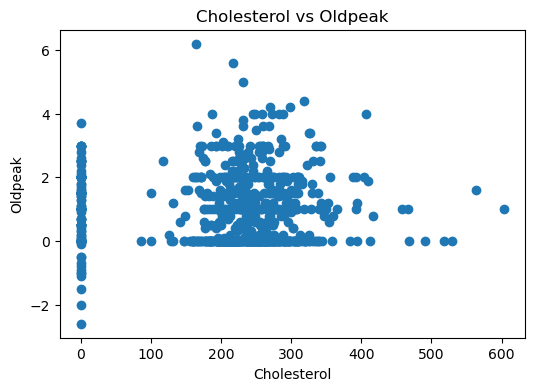

In [8]:
# -----------------------------
# Correlation
# -----------------------------
correlation = df["chol"].corr(df["oldpeak"])

print("\nCorrelation between Cholesterol and Oldpeak:")
print(correlation)

# -----------------------------
# Scatter Plot
# -----------------------------
plt.figure(figsize=(6,4))
plt.scatter(df["chol"], df["oldpeak"])

plt.xlabel("Cholesterol")
plt.ylabel("Oldpeak")
plt.title("Cholesterol vs Oldpeak")

plt.show()

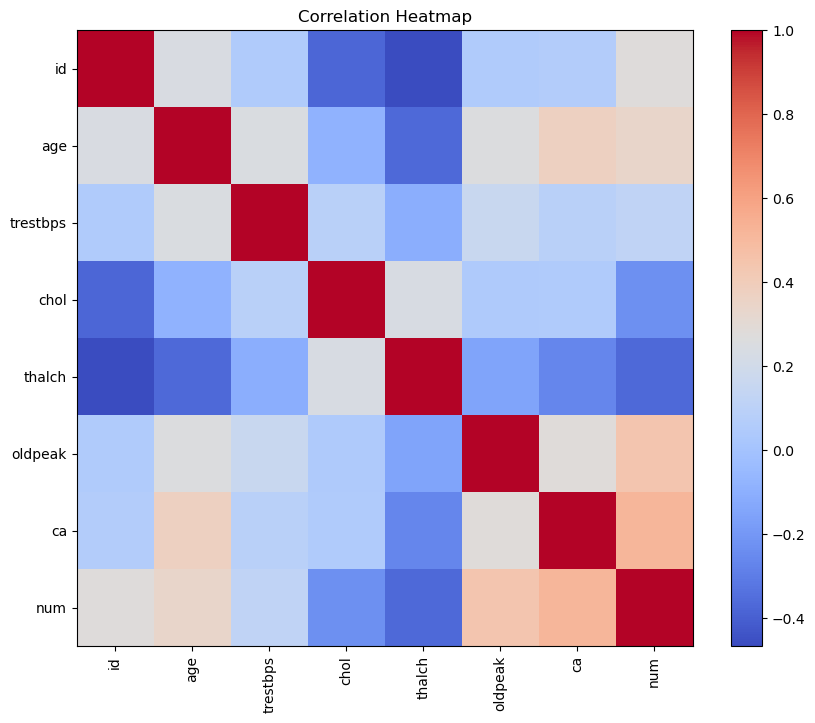

In [18]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [33]:
X = df.iloc[:, :-1]

y = df.iloc[:, -1]

In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Check missing values
print(df.isnull().sum())
df = df.fillna(df.mean(numeric_only=True))
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

from sklearn.preprocessing import StandardScaler

X = df.iloc[:, :-1]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original Features:", X.shape[1])

print("Reduced Features:", X_pca.shape[1])

Original Features: 15
Reduced Features: 13


/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


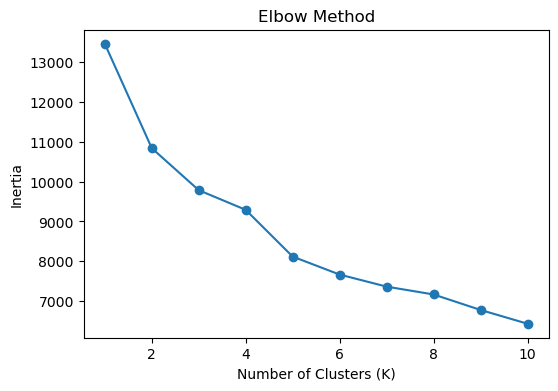

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(X_pca)

    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(6,4))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [38]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_pca)

print(clusters)

[2 2 2 2 0 0 2 2 2 2 2 2 2 0 0 0 0 0 0 0 2 2 2 2 2 0 0 2 0 2 2 2 0 0 0 0 2
 2 2 2 2 0 2 2 2 2 0 2 2 2 0 0 0 0 2 2 0 0 2 2 2 2 2 0 2 2 2 0 2 2 2 2 2 2
 0 2 2 2 0 2 2 2 0 2 0 0 0 0 0 0 2 2 2 0 0 0 2 2 2 0 0 0 2 2 2 0 2 2 2 0 2
 2 0 2 2 0 0 0 2 2 2 2 2 2 2 0 2 2 0 0 0 0 0 0 0 2 2 2 0 2 0 0 0 2 2 0 2 0
 0 0 0 2 2 2 2 2 0 2 2 2 0 2 0 2 0 0 0 2 0 0 2 2 2 2 2 2 2 2 0 2 0 2 2 2 2
 2 0 2 2 2 0 2 2 2 2 2 2 2 0 0 0 2 0 0 0 2 2 2 0 2 0 0 0 2 0 0 0 2 2 0 0 0
 0 2 2 0 0 2 2 2 0 2 2 2 0 2 2 0 0 0 0 0 0 2 0 2 0 2 2 2 2 2 2 0 0 0 2 2 2
 0 0 2 0 0 2 2 0 2 0 0 2 2 2 2 2 2 2 0 2 2 2 0 2 0 0 2 2 0 0 0 2 0 2 2 2 0
 2 2 0 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 2 0 0 0 0 0 0 0
 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 2 0 0 1 0 0 0 0 0
 0 0 2 0 0 0 1 1 0 0 0 0 

In [39]:
df["Cluster"] = clusters

print(df.head())

   id  age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   1   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   2   67    1        0   0     160.0  286.0    0        0   108.0      1   
2   3   67    1        0   0     120.0  229.0    0        0   129.0      1   
3   4   37    1        0   2     130.0  250.0    0        1   187.0      0   
4   5   41    0        0   1     130.0  204.0    0        0   172.0      0   

   oldpeak  slope   ca  thal  num  Cluster  
0      2.3      0  0.0     0    0        2  
1      1.5      1  3.0     1    2        2  
2      2.6      1  2.0     2    1        2  
3      3.5      0  0.0     1    0        2  
4      1.4      2  0.0     1    0        0  


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    clusters,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(736, 13)
(184, 13)


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9619565217391305


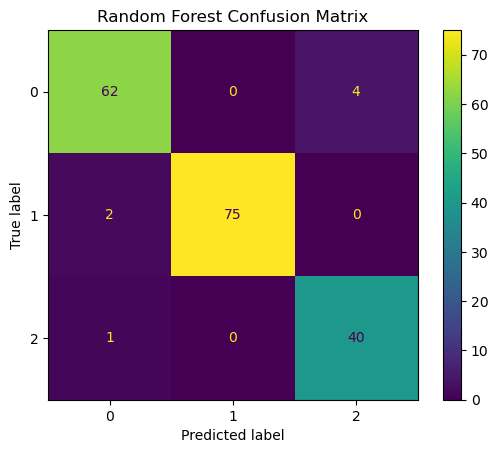

In [42]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(rf_cm).plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [43]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9728260869565217


In [44]:
print("Random Forest Accuracy:", rf_accuracy)

print("SVM Accuracy:", svm_accuracy)

Random Forest Accuracy: 0.9619565217391305
SVM Accuracy: 0.9728260869565217


In [45]:
print("Random Forest Accuracy:", rf_accuracy)

print("SVM Accuracy:", svm_accuracy)

Random Forest Accuracy: 0.9619565217391305
SVM Accuracy: 0.9728260869565217
